In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Read final dataset into csv file 
crop_yield = pd.read_csv("../data/final_crop_yield_df")

In [11]:
crop_yield.head()

,county,year,crop_type,yield_bu_acre,PRCP,TMAX,TMIN,water_storage_0_25in,water_storage_0_50in,water_storage_0_100in,...,drainage_well,wettest_excessive,wettest_moderate,wettest_poor,wettest_somewhat_excessive,wettest_somewhat_poor,wettest_very_poor,wettest_well,soil_ph_avg,organic_matter_avg
0,Bedford,2000,CORN,108.0,4.490833,71.025,47.475000,4.025817,7.452896,13.134498,...,0.751918,0.0,0.117521,0.024722,0.04316,0.056672,0.0,0.751933,5.777047,1.057655
1,Bedford,2000,SOYBEANS,24.0,4.490833,71.025,47.475000,4.025817,7.452896,13.134498,...,0.751918,0.0,0.117521,0.024722,0.04316,0.056672,0.0,0.751933,5.777047,1.057655
2,Bedford,2000,WHEAT,46.0,4.490833,71.025,47.475000,4.025817,7.452896,13.134498,...,0.751918,0.0,0.117521,0.024722,0.04316,0.056672,0.0,0.751933,5.777047,1.057655
3,Bedford,2001,CORN,130.0,4.993333,70.675,47.933333,4.025817,7.452896,13.134498,...,0.751918,0.0,0.117521,0.024722,0.04316,0.056672,0.0,0.751933,5.777047,1.057655
4,Bedford,2001,SOYBEANS,44.0,4.993333,70.675,47.933333,4.025817,7.452896,13.134498,...,0.751918,0.0,0.117521,0.024722,0.04316,0.056672,0.0,0.751933,5.777047,1.057655


In [12]:
crop_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3856 entries, 0 to 3855
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   county                       3856 non-null   object 
 1   year                         3856 non-null   int64  
 2   crop_type                    3856 non-null   object 
 3   yield_bu_acre                3856 non-null   float64
 4   PRCP                         3651 non-null   float64
 5   TMAX                         3651 non-null   float64
 6   TMIN                         3651 non-null   float64
 7   water_storage_0_25in         3750 non-null   float64
 8   water_storage_0_50in         3750 non-null   float64
 9   water_storage_0_100in        3750 non-null   float64
 10  water_storage_0_150in        3750 non-null   float64
 11  typical_slope_steepness      3750 non-null   float64
 12  mean_slope_weighted          3750 non-null   float64
 13  bedrock_depth_min 

In [19]:
#Percentage of missing values
(crop_yield.isnull().mean()*100).sort_values(ascending=False)

PRCP                           5.316390
TMAX                           5.316390
TMIN                           5.316390
drain_C_low                    2.748963
wettest_excessive              2.748963
drainage_moderate              2.748963
drainage_poor                  2.748963
drainage_somewhat_excessive    2.748963
drainage_somewhat_poor         2.748963
drainage_very_poor             2.748963
drainage_well                  2.748963
wettest_poor                   2.748963
wettest_moderate               2.748963
drain_D_very_low               2.748963
wettest_somewhat_excessive     2.748963
wettest_somewhat_poor          2.748963
wettest_very_poor              2.748963
wettest_well                   2.748963
soil_ph_avg                    2.748963
drainage_excessive             2.748963
organic_matter_avg             2.748963
drain_CD                       2.748963
bedrock_depth_min              2.748963
water_storage_0_25in           2.748963
water_storage_0_50in           2.748963


In [23]:
# Check the missing weather patterns
crop_yield["PRCP_missing"] = crop_yield["PRCP"].isnull().astype(int)
crop_yield["TMAX_missing"] = crop_yield["TMAX"].isnull().astype(int)
crop_yield["TMIN_missing"] = crop_yield["TMIN"].isnull().astype(int)

In [24]:
crop_yield["PRCP_missing"]

0       0
1       0
2       0
3       0
4       0
       ..
3851    0
3852    0
3853    0
3854    0
3855    0
Name: PRCP_missing, Length: 3856, dtype: int64

In [27]:
crop_yield.groupby("county")[["PRCP_missing","TMAX_missing","TMIN_missing"]].mean().sort_values("PRCP_missing", ascending=False)

,PRCP_missing,TMAX_missing,TMIN_missing
county,,,
Other Counties,1.000000,1.000000,1.000000
Lake,1.000000,1.000000,1.000000
Other (Combined) Counties,1.000000,1.000000,1.000000
De Kalb,1.000000,1.000000,1.000000
Trousdale,0.166667,0.166667,0.166667
...,...,...,...
Hamilton,0.000000,0.000000,0.000000
Hamblen,0.000000,0.000000,0.000000
Grundy,0.000000,0.000000,0.000000


In [29]:
county_missing_pct[county_missing_pct["PRCP_missing"] > 0]

,PRCP_missing,TMAX_missing,TMIN_missing
county,,,
Other Counties,1.000000,1.000000,1.000000
Lake,1.000000,1.000000,1.000000
Other (Combined) Counties,1.000000,1.000000,1.000000
De Kalb,1.000000,1.000000,1.000000
Trousdale,0.166667,0.166667,0.166667
Macon,0.160714,0.160714,0.160714
Grainger,0.160000,0.160000,0.160000
Lauderdale,0.130435,0.130435,0.130435
Chester,0.115385,0.115385,0.115385


Looks like few counties does not have any weather information. 
Some counties have partial weather information

In [32]:
# Check the missing soil patterns
soil_cols = ["soil_ph_avg","organic_matter_avg"]

crop_yield["soil_missing"] = crop_yield[soil_cols].isnull().any(axis=1).astype(int)

crop_yield.groupby("county")["soil_missing"].mean().sort_values(ascending=False)

county
Other Counties               1.0
De Kalb                      1.0
Other (Combined) Counties    1.0
Bedford                      0.0
Monroe                       0.0
                            ... 
Grundy                       0.0
Greene                       0.0
Grainger                     0.0
Giles                        0.0
Wilson                       0.0
Name: soil_missing, Length: 90, dtype: float64

Looks like 3 counties does not have any soil information

In [33]:
# Analyze the target variable
crop_yield["yield_bu_acre"].describe()

count    3856.000000
mean       81.215379
std        47.567783
min         9.000000
25%        43.600000
50%        59.700000
75%       120.075000
max       201.500000
Name: yield_bu_acre, dtype: float64

50% crops are below 60 BU/acre but top 25% go very high 120+ bu/acre.

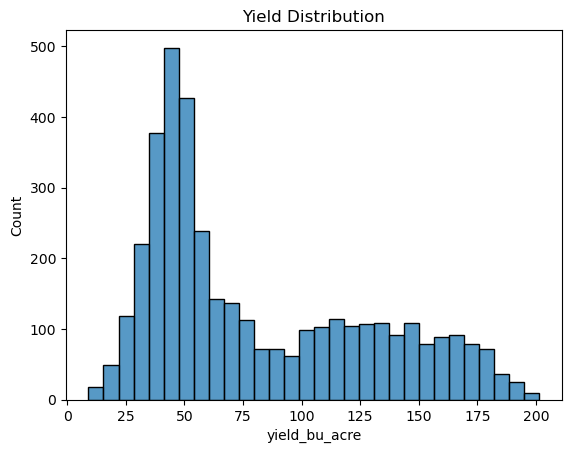

In [37]:
# Histogram for crop yield Distribution
sns.histplot(crop_yield["yield_bu_acre"], bins=30)
plt.title("Yield Distribution")
plt.show()

Looks like Crop yield distribution is right skewed and it is not normally distributed.

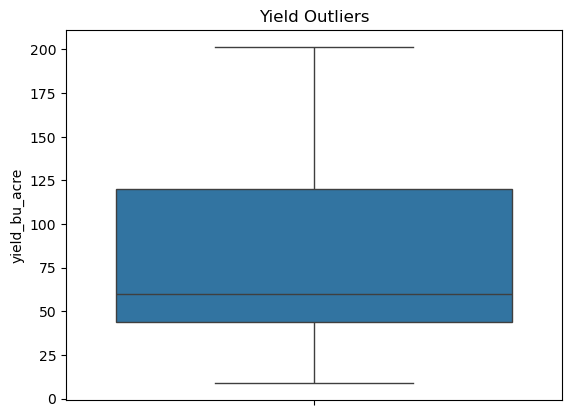

In [40]:
# Check outliers by using box plot
sns.boxplot(crop_yield["yield_bu_acre"])
plt.title("Yield Outliers")
plt.show()

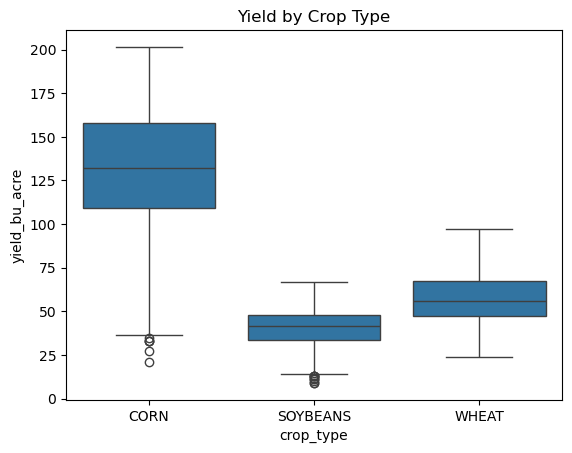

In [45]:
# Check Yield by crop_type
sns.boxplot(data=crop_yield, x="crop_type", y="yield_bu_acre")
plt.title("Yield by Crop Type")
plt.show()

Looks like Corn and Soybeans has outliers with below 30 and 15. And the corn median is very high compared to other crop types.
looks like Corn produce high yields and has large variation.

<Axes: xlabel='year'>

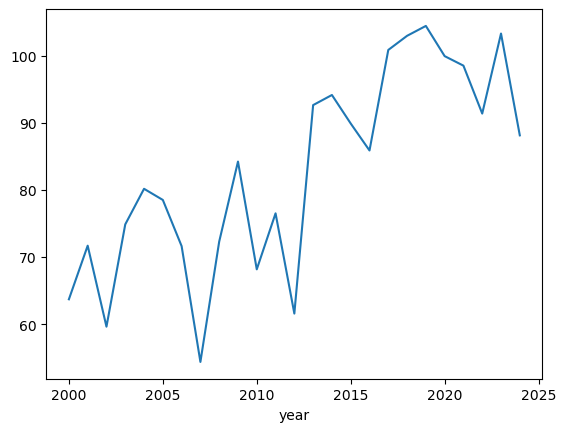

In [47]:
# Check yearly yield trends
crop_yield.groupby("year")["yield_bu_acre"].mean().plot()


In [ ]:
# Weather Relationships with yield value

<Axes: xlabel='PRCP', ylabel='yield_bu_acre'>

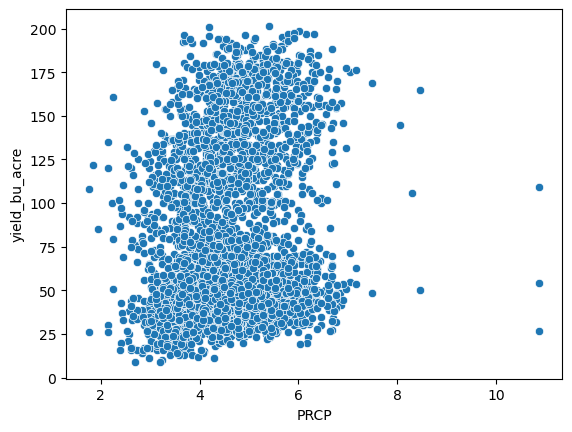

In [55]:
sns.scatterplot(data=crop_yield, x="PRCP", y="yield_bu_acre")

<Axes: xlabel='PRCP', ylabel='yield_bu_acre'>

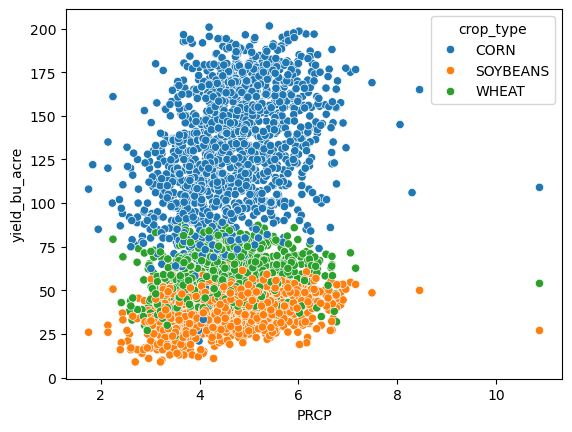

In [51]:
sns.scatterplot(data=crop_yield, x="PRCP", y="yield_bu_acre",hue="crop_type")

<Axes: xlabel='TMAX', ylabel='yield_bu_acre'>

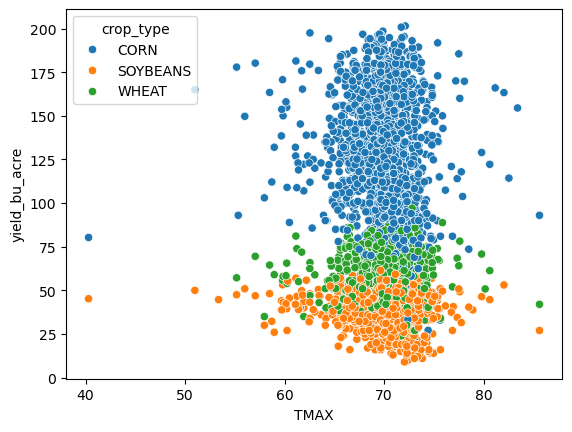

In [63]:
sns.scatterplot(data=crop_yield, x="TMAX", y="yield_bu_acre",hue="crop_type")

<Axes: xlabel='TMIN', ylabel='yield_bu_acre'>

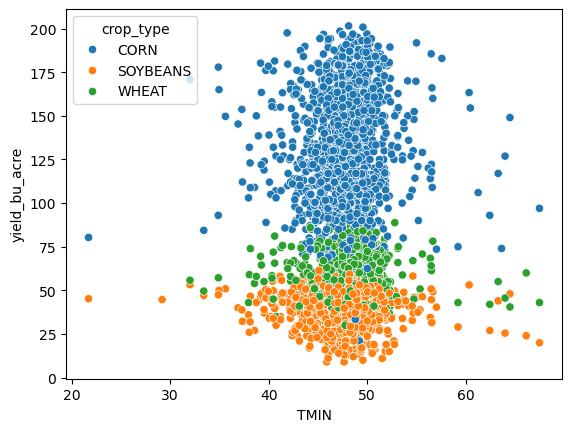

In [64]:
sns.scatterplot(data=crop_yield, x="TMIN", y="yield_bu_acre",hue="crop_type")

array([[<Axes: title={'center': 'soil_ph_avg'}>,
        <Axes: title={'center': 'organic_matter_avg'}>],
       [<Axes: title={'center': 'water_storage_0_150in'}>, <Axes: >]],
      dtype=object)

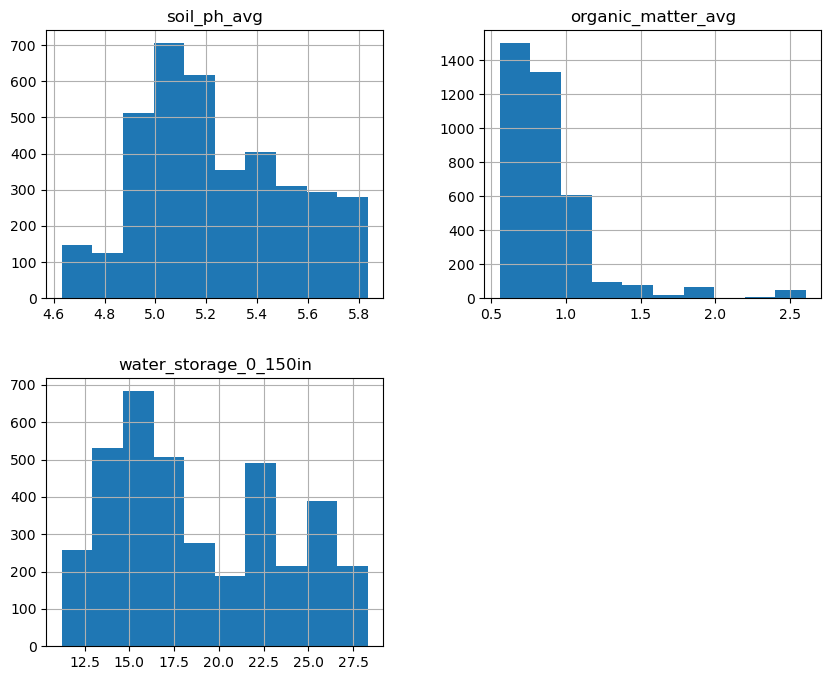

In [69]:
soil_cols = ["soil_ph_avg","organic_matter_avg","water_storage_0_150in"]
crop_yield[soil_cols].hist(
    figsize=(10,8)
)

In [66]:
crop_yield["soil_ph_avg"].describe()

count    3750.000000
mean        5.230556
std         0.292472
min         4.631724
25%         5.008674
50%         5.181712
75%         5.434055
max         5.834707
Name: soil_ph_avg, dtype: float64

Optimal Agricultural PH = 6.0 - 7.0
but in our data Ph values are 4.6-5.8 (mostly acidic) in all counties
small changes near acidic conditions affect nutrient availability strongly.

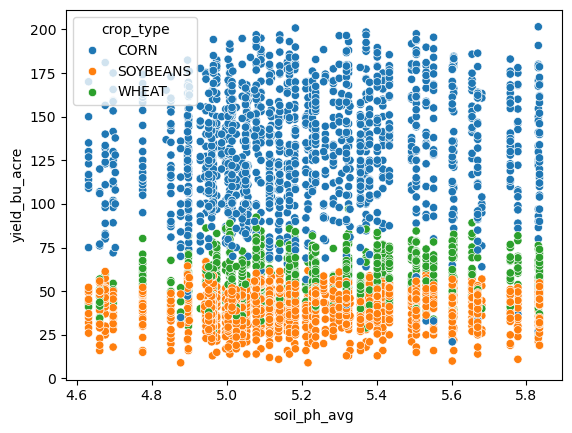

In [67]:
sns.scatterplot(data=crop_yield,x="soil_ph_avg",y="yield_bu_acre",hue = "crop_type")
plt.show()